# **Tugas Akhir IF5250 Deep Learning**

# **Audio-CRNN-Benchmarking-ESC-50**

||Identitas|
|--|--|
|Nama|Siti Ramadina Goethe K.|
|NIM|15322001|
|Kode Mahasiswa|MHS-06|
|Dataset|[ESC-50](https://github.com/karolpiczak/ESC-50)|

# Bagian 1:  Persiapan Awal

## 1.1 Import Libraries & Setup Random Seed

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"CUDA avalailable: {torch.cuda.is_available()}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print("Setup complete.")

CUDA avalailable: True
PyTorch version: 2.11.0+cu128
Device: cuda
Setup complete.


In [ ]:
# Dictionary config.yaml untuk menyimpan hyperparameter
crnn_config = {
    # spectrum
    sample_rate =
    n_fft =
    n_mels =
    hop_length =
    win_length =
    f_max =

    # model and optimizer
    model_arch = 'crnn',
    optimizer = 'adam',

    # training
    learning_rate = 1e-3,
    batch_size = 32,
    n_epochs = ,
    normalize = ,

    # data
    trial_num =
    fold =
}

# ResNet-18
resnet8_config = {
    # spectrum
    sample_rate =
    n_fft =
    n_mels =
    hop_length =
    win_length =
    f_max =

    # model and optimizer
    model_arch = 'crnn',
    optimizer = 'adam',

    # training
    learning_rate = 1e-3,
    batch_size = 32,
    n_epochs = ,
    normalize = ,

    # data
    trial_num =
    fold =
}

# ViT Audio
vit_config = {
    # spectrum
    sample_rate =
    n_fft =
    n_mels =
    hop_length =
    win_length =
    f_max =

    # model and optimizer
    model_arch = 'crnn',
    optimizer = 'adam',

    # training
    learning_rate = 1e-3,
    batch_size = 32,
    n_epochs = ,
    normalize = ,

    # data
    trial_num =
    fold =
}

## 1.2 Download dan Load Dataset ESC-50

In [ ]:
# Unduh otomatis dari GitHub
if not os.path.exists('ESC-50-master'):
  !wget https://github.com/karoldvl/ESC-50/archive/master.zip
  !unzip -oq master.zip
  print("Selesai mengunduh dataset ESC-50 dari GitHub")
else:
  print("Dataset ESC-50 sudah tersedia.")


--2026-05-29 04:32:18--  https://github.com/karoldvl/ESC-50/archive/master.zip
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/karolpiczak/ESC-50/archive/master.zip [following]
--2026-05-29 04:32:18--  https://github.com/karolpiczak/ESC-50/archive/master.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/karolpiczak/ESC-50/zip/refs/heads/master [following]
--2026-05-29 04:32:19--  https://codeload.github.com/karolpiczak/ESC-50/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.121.10
Connecting to codeload.github.com (codeload.github.com)|140.82.121.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [   

In [ ]:
# Baca data
csv_path = '/content/ESC-50-master/meta/esc50.csv'
wav_dir_path = '/content/ESC-50-master/audio'

df = pd.read_csv(csv_path)
print(f"Total data: {len(df)} sampel")
df.head()

Total data: 2000 sampel


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


## 1.3 Konversi File Audio ke Mel-Spectogram

In [ ]:
# Konversi ke melspectogram
mel_spectogram = T.MelSpectrogram(
    sample_rate = 22050,
    n_fft = 1024,
    hop_length = 512,
    n_mels = 128,
)

# Ubah audio ke Log-Mel-Spectogram
def log_mel_spec(path):
  waveform, sample_rate = torchaudio.load(path)
  mel_spec = mel_spectogram(waveform)
  log_mel = T.AmplitudeToDB(mel_spec, top_db=80)(mel_spec)
  return log_mel[0]

In [ ]:
# Kelas ESC-50 Dataset
class ESC50Dataset(Dataset):
  def __init__(self, df, wav_dir, transform=None):
    self.df = df
    self.wav_dir = wav_dir
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    wav_name = self.df.iloc[idx]['filename']
    label = self.df.iloc[idx]['target']
    audio_path = os.path.join(self.wav_dir, wav_name)

    # Ambil mel-spec
    mel_spec = log_mel_spec(audio_path)
    mel_spec = mel_spec.unsqueeze(0) # tambah dimensi channel (1, freq, t)
    return mel_spec, label

dataset = ESC50Dataset(df, wav_dir_path)

Id: 1126 | Label: 6 | Kategori: hen
Ukuran Tensor Spectogram: torch.Size([1, 128, 431]) (Ch, Mel, t)


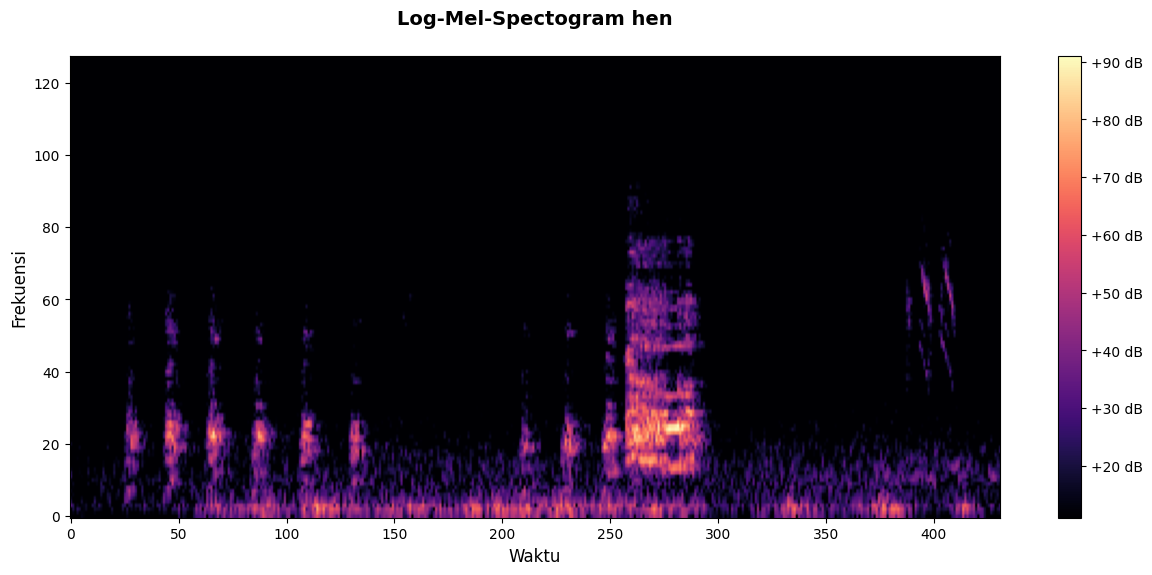

In [ ]:
# Contoh representasi visual dari suara (spektorgram)

# Pilih satu sampel acak
idx = np.random.randint(0, len(dataset))
mel, label = dataset[idx]
category = df.iloc[idx]['category']

print(f"Id: {idx} | Label: {label} | Kategori: {category}")
print(f"Ukuran Tensor Spectogram: {mel.shape} (Ch, Mel, t)")

plt.figure(figsize=(15,6))
plt.imshow(mel[0].numpy(), origin='lower', aspect='auto', cmap='magma')
plt.title(f"Log-Mel-Spectogram {category}", fontsize=14, y=1.05, fontweight='bold')
plt.xlabel("Waktu", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.colorbar(format="%+2.0f dB") # tambah satuan pada bar
plt.show()


## 1.4 Implementasi 5-Fold Cross-Validation

Fold adalah melakukan partisi data dengan jumlah yang sama besar.

In [ ]:
# Implementasi 5-Fold Cross-Validation
# Fold 1-3 train
# Fold 4 validation
# Fold 5 test

train_df = df[df['fold'].isin([1,2,3])].reset_index(drop=True)
val_df = df[df['fold']==4].reset_index(drop=True)
test_df = df[df['fold']==5].reset_index(drop=True)

## 1.5 Data Loader

In [ ]:
# DataLoader (Training, Validation, Test)
BATCH_SIZE = 32

train_dataset = ESC50Dataset(train_df, wav_dir_path)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = ESC50Dataset(val_df, wav_dir_path)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = ESC50Dataset(test_df, wav_dir_path)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Jumlah data latih: {len(train_df)}")
print(f"Jumlah data validasi: {len(val_df)}")
print(f"Jumlah data uji: {len(test_df)}")

# Contoh 1 batch
feat, label = next(iter(train_loader))
print(f"Ukurang bacth input: {feat.shape}")
print(f"Ukuran bacth label: {label.shape}")

Jumlah data latih: 1200
Jumlah data validasi: 400
Jumlah data uji: 400
Ukurang bacth input: torch.Size([32, 1, 128, 431])
Ukuran bacth label: torch.Size([32])


# Bagian 2: Arsitektur Model

[Boddapati, 2017](https://github.com/bkasvenkatesh/Classifying-Environmental-Sounds-with-Image-Networks/blob/master/CRNN.py)

## Model Utama: CRNN

In [ ]:
# Kelas CNN dan RNN
class CRNN(nn.Module):
  def __init__(self, input_size, hidden_size, num_layers, num_classes=50):
    super(CRNN, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    # Model CNN untuk ekstraksi fitur
    # Input (B, Ch=1, f=128, t=216)
    self.cnn = nn.Sequential(
        # Layer 1
        nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2), # Out = (32, 64, 108)
        # Layer 2
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2, padding=1), # Out = (64,32,54)
        # Layer 3
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2), # Out = (128, 16,27)
        # Layer 4
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    # Model sekuensial LSTM
    self.lstm = nn.LSTM(
        input_size = 256*8,
        hidden_size = 128,
        num_layers = 2,
        batch_first = True,
        bidirectional = True
    )


    # Model sekuensial RNN --> GRU
    self.rnn = nn.GRU(
        input_size,
        hidden_size,
        num_layers,
        batch_first=True,
        bidirectional=True
    )

    # Classifier
    self.classifier = nn.Linear(hidden_size*2, num_classes)

  def forward(self, x):
    # x shape = [b, 1, 128, 216]
    # CNN
    x = self.cnn(x)
    x = x.permute(0,3,1,2) # ubaah [batch, ch, f, t] jadi [batch, t, ch, f]
    batch, t, ch, f = x.size()
    x = x.reshape(batch, t, ch*f)

    # RNN
    lstm_out, _ = self.lstm(x)
    feat = lstm_out[:, -1, :]
    out = self.classifier(feat)
    return out

model = CRNN(input_size=64, hidden_size=128, num_layers=2, num_classes=50)
dummy = torch.randn(4,1,128,216)
output = model(dummy)
print(output.shape)

print(f"bentuk input:{dummy.shape}")
print(f"bentuk output: {output.shape}")


torch.Size([4, 50])
bentuk input:torch.Size([4, 1, 128, 216])
bentuk output: torch.Size([4, 50])


1. Downsampling (maxpool) 4 layer --> tinggi spektogram (f) 128 px --> 8 px

128/(2.2.2.2)=8

2. Permute & reshap : putar data agar dimensi waktu menjadi urutan utama yang dibaca oleh LSTM

3. pakai bilstm agar model bisa memahami konteks suara dari depan atau blkg

4. penultimate layer: lstm_out[], akan digunakan untuk tugas rsm. isi otak model sebelum menebak kelas suara.


1. Apakah Arsitektur CRNN itu "Baku"?
Jawabannya: Tidak. CRNN hanyalah sebuah konsep hibrida (CNN + RNN). Ibarat resep nasi goreng, bumbu dasarnya sama (nasi dan kecap), tapi isi dan teknik memasaknya bisa berbeda-beda.
Variasi yang bisa Anda ubah agar model ini menjadi "milik Anda" dan unik:
Jumlah Layer CNN: Anda bisa memakai 3, 4, atau 5 layer.
Jumlah Filter: Anda bisa memakai urutan 16-32-64 atau 32-64-128-256.
Jenis RNN: Anda bisa mengganti LSTM dengan GRU (lebih ringan) atau menggunakan satu arah (unidirectional) saja.
Aktivasi: Anda bisa mengganti ReLU dengan LeakyReLU atau ELU.
Regularisasi: Menambahkan Dropout pada layer tertentu untuk mencegah overfitting.
2. Bagaimana Menyiasati Kode agar Tidak Dianggap Plagiat?
Untuk menghindari kesan copy-paste buta, lakukan langkah-langkah ini:
A. Modifikasi Parameter (Tweak)
Jangan pakai angka yang persis saya berikan. Misalnya:
Jika saya berikan kernel_size=3, Anda bisa mencoba kernel_size=5 pada layer pertama.
Jika saya berikan hidden_size=128, coba gunakan hidden_size=64 atau 256.
Tambahkan nn.Dropout(0.2) setelah layer CNN atau RNN.
B. Pahami "Mengapa"-nya dan Tulis di Laporan
Dosen biasanya tidak hanya melihat kodenya, tapi narasi Anda di Bab 3 (Metodologi) dan Bab 7 (Diskusi).
Contoh: "Saya memilih menggunakan 3 layer CNN dengan filter yang meningkat secara progresif (32, 64, 128) agar model dapat menangkap fitur spasial dari spektrogram secara hierarkis..."
Kalimat seperti ini membuktikan bahwa Anda paham, bukan sekadar menempel kode.
C. Gunakan Dokumentasi Resmi sebagai Referensi
Anda tidak perlu membaca seluruh dokumentasi PyTorch dari nol (itu akan menghabiskan waktu). Cukup gunakan sebagai "Kamus".
Jika Anda menggunakan nn.Conv2d, buka dokumentasi PyTorch Conv2d hanya untuk melihat parameter apa saja yang bisa Anda ganti.
3. Strategi "Efisiensi Waktu" yang Aman
Daripada belajar dari nol atau copy-paste total, gunakan metode "Template as a Guide":
Gunakan struktur data loader yang saya berikan: Bagian ini biasanya bersifat standar (boilerplate). Hampir semua orang menggunakan cara yang mirip untuk me-load audio. Ini risiko plagiasinya rendah karena memang cara kerjanya begitu.
Buat variasi pada kelas Model: Ubah jumlah layer atau ukuran filter sesuai poin #1 di atas.
Berikan Komentar (Comment) di Setiap Baris Kode: Tulis penjelasan dengan bahasa Anda sendiri di samping baris kode. Ini sangat membantu membuktikan orisinalitas pemikiran Anda.
Saran Praktis untuk MHS-06:
Agar arsitektur Anda berbeda dari mahasiswa lain, cobalah gunakan GRU sebagai pengganti LSTM.
Alasannya: GRU memiliki parameter lebih sedikit dan seringkali performanya setara dengan LSTM untuk tugas klasifikasi suara pendek (5 detik). Ini bisa menjadi poin menarik di laporan Anda: "Saya memilih GRU karena keterbatasan resource dan durasi audio yang singkat..."
Apakah Anda ingin saya tunjukkan bagaimana mengubah LSTM tadi menjadi GRU dan menambahkan Dropout agar modelnya lebih "khas" dan aman secara akademis?

## Model Pembanding 1 (Baseline): ResNet-18

In [ ]:
# Adaptasi ResNet-18 untuk input spectogram (1 ch)
class resnet18(nn.Module):
  def __init__(self, num_classes=50, pretrained=True):
    super(ResNet18Audio, self).__init__()
    self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)



class ResNet18Audio(nn.Module):
    def __init__(self, num_classes=50, pretrained=True):
        super(ResNet18Audio, self).__init__()

        # 1. Load model asli dari torchvision
        # Menggunakan weights=ResNet18_Weights.DEFAULT (cara terbaru di PyTorch)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)

        # 2. Modifikasi Input Layer (Conv1)
        # ResNet aslinya menerima 3 channel, kita ubah jadi 1 channel
        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64,
                                      kernel_size=original_conv.kernel_size,
                                      stride=original_conv.stride,
                                      padding=original_conv.padding,
                                      bias=False)

        # Opsional: Salin bobot dari salah satu channel asli ke channel baru kita
        # agar tidak kehilangan kemampuan deteksi fitur awal.
        with torch.no_grad():
            self.resnet.conv1.weight[:] = original_conv.weight[:, 0:1, :, :]

        # 3. Modifikasi Output Layer (FC)
        # ResNet aslinya 1000 kelas, kita ubah jadi 50 kelas
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.resnet(x)

# Inisialisasi model
model_resnet = ResNet18Audio(num_classes=50, pretrained=True).to(device)

## Model Pembanding 2 (SOTA): ViT Audio

In [ ]:
# Implementasi Vision Transformer untuk audio


# Bagian 3: Training & Testing Pipeline

In [ ]:
# Fungsi Training Umum
def train(model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for batch_idx, (input, target) in enumerate(loader):
    input, target = input.to(device), target.to(device)

    # Mengosongkan gradien
    optimizer.zero_grad()

    # Forward pass (prediksi)
    output = model(input)

    # Menghitung loss
    loss = criterion(output, target)

    # Backward pass
    loss.backward()

    # Perbarui bobot
    optimizer.step()
    running_loss += loss.item()
    _, predicted = torch.max(output.data, 1)
    total += target.size(0)
    correct += (predicted == target).sum().item()

    epoch_loss =  running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

print("Funsgi training untuk 1 epoch telah dibuat.")

Funsgi training untuk 1 epoch telah dibuat.
mulai training 1 epoch
selesai
(0.12279003858566284, 3.125)


In [ ]:
# Fungsi Validasi
def validate(model, loader, criterion, device):
  model.eval()
  running_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():
    for input, target in loader:
      input, target = input.to(device), target.to(device)
      output = model(input)
      loss = criterion(output, target)
      running_loss += loss.item()
      _, predicted = torch.max(output.data, 1)
      total += target.size(0)
      correct += (predicted == target).sum().item()

      loss = running_loss/total
      acc = 100. * correct/total

    return loss, acc

  print('Fungsi validasi umum telah dibuat')

In [ ]:
# Coba Loop Utama untuk Model CRNN

crnn_model = CRNN(input_size=64, hidden_size=128, num_layers=2, num_classes=50).to(device)
criterion = nn.CrossEntropyLoss() # fungsi loss utk klasifikasi
optimizer = optim.Adam(crnn_model.parameters(), lr=1e-3)

# Untuk menyimpan hasil
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0 # Model terbaik
epochs = 50

for epoch in range(epochs):
  train_loss, train_acc = train(crnn_model, train_loader, criterion, optimizer, device)
  val_loss, val_acc = validate(crnn_model, val_loader, criterion, device)

  history['train_loss'].append(train_loss)
  history['train_acc'].append(train_acc)
  history['val_loss'].append(val_loss)
  history['val_acc'].append(val_acc)

  print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f} |")

  # Simpan model terbaik
  if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(crnn_model.state_dict(), 'best_model.pth')
    print("Model terbaik disimpan.")
  print("-"*30)

Epoch 1/50 | Train loss: 0.1221 | Train acc: 6.25 | Val loss: 0.1267 | Val acc: 4.75 |
Model terbaik disimpan.
------------------------------
Epoch 2/50 | Train loss: 0.1216 | Train acc: 3.12 | Val loss: 0.1264 | Val acc: 4.50 |
------------------------------
Epoch 3/50 | Train loss: 0.1216 | Train acc: 9.38 | Val loss: 0.1262 | Val acc: 4.50 |
------------------------------
Epoch 4/50 | Train loss: 0.1205 | Train acc: 6.25 | Val loss: 0.1259 | Val acc: 4.25 |
------------------------------
Epoch 5/50 | Train loss: 0.1197 | Train acc: 6.25 | Val loss: 0.1255 | Val acc: 4.25 |
------------------------------
Epoch 6/50 | Train loss: 0.1208 | Train acc: 3.12 | Val loss: 0.1251 | Val acc: 6.00 |
Model terbaik disimpan.
------------------------------
Epoch 7/50 | Train loss: 0.1191 | Train acc: 6.25 | Val loss: 0.1247 | Val acc: 6.50 |
Model terbaik disimpan.
------------------------------
Epoch 8/50 | Train loss: 0.1191 | Train acc: 6.25 | Val loss: 0.1243 | Val acc: 6.00 |
---------------

In [ ]:
# Loop Pelatihan dan Validasi untuk 3 Model
models = ['CRNN', 'ResNet-18', 'ViT']
epochs = 50
best_val_acc = 0.0

# Loop latihan metiap model
for model in models:
  print(f"Training {model} model")

  if model == 'CRNN':
    model = CRNN(input_size=64, hidden_size=128, num_layers=2, num_classes=50).to(device)

  elif model == 'ResNet-18':
    model = resnet18()

  else: # model == "ViT"
    model = vit()

  optimizer = optim.Adam(model.parameters(), lr=1e-3)
  criterion = nn.CrossEntropyLoss()

  # Loop utama
  for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f} |")

    # Simpan checkpoint model terbaik
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(crnn_model.state_dict(), 'best_model.pth')
      print("Model terbaik disimpan.")
    print("-"*30)

SyntaxError: invalid syntax (2088572286.py, line 14)

In [ ]:
# Visualisasi Kurva Pelatihan (Loss dan Akurasi)

def history_plot(history, model_name):
  epochs = range(1, len(history['train_loss'])+1)

  # Loss vs Epoch
  fig, axes = plt.subplots(1, 2, figsize=(12,5))
  axes[0].plot(epochs, history['train_loss'], label='Train Loss')
  axes[0].plot(epochs, history['val_loss'], label='Validation Loss')
  axes[0].set_title('Loss vs Epoch')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Loss')
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  # Accuracy vs Epoch
  axes[1].plot(epochs, history['train_acc'], label='Train Accuracy')
  axes[1].plot(epochs, history['val_acc'], label='Validation Accuracy')
  axes[1].set_title('Accuracy vs Epoch')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Accuracy')
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  fig.savefig(f"{model_name}_train_curve.png")
  plt.tight_layout()
  plt.show()

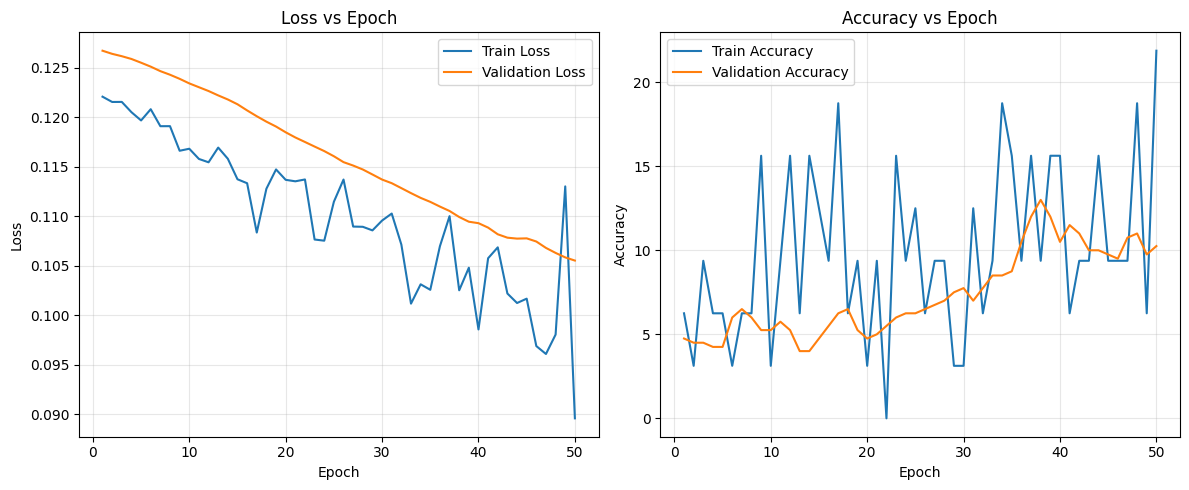

None

In [ ]:
# Contoh visualisasi loss dan akurasi model CRNN
test_crnn = history_plot(history, 'CRNN')
display(test_crnn)

In [ ]:
# Visualisasi seluruh model
models = ['CRNN', 'ResNet18', 'ViT']

for model in models:
  vis_model = history_plot(history, model)
  display(vis_model)

# Bagian 4: Evaluasi dan Benchmarking

Evaluasi semua model pada Test Set (Fold 5).
TODO: Hitung Accuracy, Precision, Recall, F1-Score (Weighted).
TODO: Buat Confusion Matrix untuk ketiga model.
TODO: Ekspor hasil ke file metrics.json sesuai format spesifikasi hal. 12.

# Bagian 5: Representational Similarity Analysis (RSM)

TODO: Load "Benchmark Set" (400 audio manifest dari dosen).
TODO: Ekstrak Embedding dari penultimate layer untuk tiap model.
TODO: Hitung Cosine Similarity Matrix (N x N).
TODO: Visualisasi Heatmap RSM dan simpan sebagai .png.


# Bagian 6: Visualisasi Saliency dan Attention

TODO: Pilih 20-30 sampel dari benchmark set.
TODO: Implementasi Saliency Map (untuk CRNN/ResNet) dan Attention Map (untuk ViT).
TODO: Simpan visualisasi untuk dibandingkan di laporan.

# Bagian 7: Ekspor Folder

TODO: Script otomatis untuk membuat struktur folder sesuai halaman 11 (model_utama, model_pembanding_1, dll).
TODO: Zip semua folder untuk diunduh.